# Pareto sweep analysis

Load a `summary.csv` or `summary.json` from a `pareto_runs/` directory and visualize the Pareto front.

**New sweeps** use seeded eval (`eval_seeds` in `summary.json`) and Pareto dominance on **`mean_acc`** (maximize) vs metabolic / wiring costs (minimize). Legacy runs still plot **`task_loss`**.

Run **eval seed calibration** (cells below) once to validate `DEFAULT_EVAL_SEEDS` in `pareto.py` (currently 10 seeds starting at 10000).

Interactive Plotly + matplotlib Pareto panels; λ-sweep row plots accuracy and costs vs λ.

## Eval seed calibration (run once)

Sweep how many fixed eval seeds are needed for stable **mean_acc** on easy tasks (`easy_task=True`, noiseless). Compare a strong vs weak checkpoint on `sanity3`; adjust `DEFAULT_EVAL_SEEDS` in `pareto.py` if curves have not plateaued by 10 seeds.

DaleRNN: N=256  frac_e=0.8  rho(W)=1.000  activation=relu
Loaded checkpoint <- /dss/dsshome1/05/di54yaw/Codes/canonical_mc/checkpoints/dale_20_50000_2026_09_05_02_50_56.pt  model=dale  tasks=['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti', 'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm', 'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm', 'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo']
DaleRNN: N=256  frac_e=0.8  rho(W)=1.000  activation=relu
Loaded checkpoint <- /dss/dsshome1/05/di54yaw/Codes/canonical_mc/checkpoints/dale_3_1000_2026_09_16_15_47_03.pt  model=dale  tasks=['fdgo', 'contextdm1', 'dmsgo']
pareto.py DEFAULT_EVAL_SEEDS = (10000, 10001, 10002, 10003, 10004, 10005, 10006, 10007, 10008, 10009)


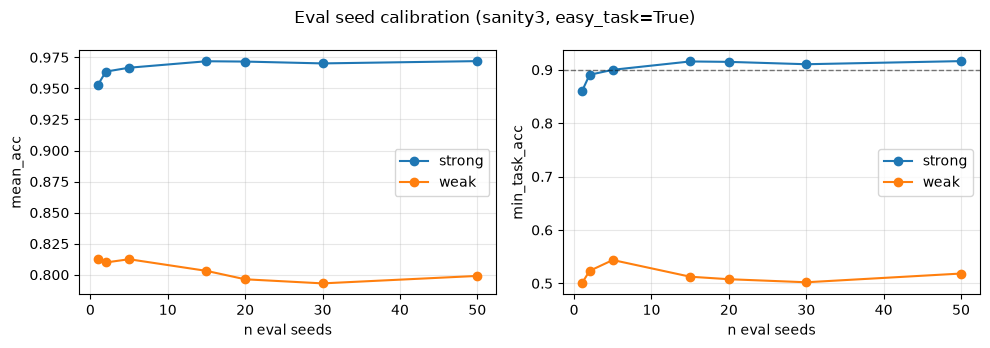

model      strong      weak
n_seeds                    
1        0.953125  0.812500
2        0.963542  0.809896
5        0.966667  0.812500
15       0.971875  0.803125
20       0.971615  0.796354
30       0.970139  0.793056
50       0.971979  0.799063


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import torch

from cmc.pareto import DEFAULT_EVAL_SEEDS
from cmc.train_cog import evaluate_pareto_metrics, load_checkpoint, resolve_active_tasks
from cmc.paths import CHECKPOINTS_DIR

CAL_TASKS = resolve_active_tasks("sanity3", None)
CAL_BATCH = 64
BASE_SEEDS = [10000 + i for i in range(50)]
N_LIST = [1, 2, 5, 15, 20, 30, 50]
FAIL_THRESH = 0.9
CHECKPOINTS = {
    "strong": CHECKPOINTS_DIR / "dale_20_50000_2026_09_05_02_50_56.pt",
    "weak": CHECKPOINTS_DIR / "dale_3_1000_2026_09_16_15_47_03.pt",
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rows = []
for label, ckpt in CHECKPOINTS.items():
    if not ckpt.is_file():
        print(f"Skip {label}: missing {ckpt}")
        continue
    model, config, _ = load_checkpoint(ckpt, device=device)
    for n in N_LIST:
        seeds = tuple(BASE_SEEDS[:n])
        m = evaluate_pareto_metrics(
            model,
            config,
            CAL_TASKS,
            device,
            eval_seeds=seeds,
            batch_size=CAL_BATCH,
            easy_task=True,
        )
        n_fail_tasks = sum(
            1 for k, v in m.items() if k.startswith("acc_") and v < FAIL_THRESH
        )
        rows.append(
            {
                "model": label,
                "n_seeds": n,
                "mean_acc": m["mean_acc"],
                "min_task_acc": m["min_task_acc"],
                "n_tasks_below_thresh": n_fail_tasks,
            }
        )

cal = pd.DataFrame(rows)
print(f"pareto.py DEFAULT_EVAL_SEEDS = {DEFAULT_EVAL_SEEDS}")
if cal.empty:
    print("No checkpoints found — update CHECKPOINTS paths and re-run.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    for label, sub in cal.groupby("model"):
        sub = sub.sort_values("n_seeds")
        axes[0].plot(sub["n_seeds"], sub["mean_acc"], "o-", label=label)
        axes[1].plot(sub["n_seeds"], sub["min_task_acc"], "o-", label=label)
    axes[0].set_xlabel("n eval seeds")
    axes[0].set_ylabel("mean_acc")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].set_xlabel("n eval seeds")
    axes[1].set_ylabel("min_task_acc")
    axes[1].axhline(FAIL_THRESH, color="k", ls="--", lw=1, alpha=0.5)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    fig.suptitle("Eval seed calibration (sanity3, easy_task=True)")
    fig.tight_layout()
    plt.show()
    print(cal.pivot(index="n_seeds", columns="model", values="mean_acc"))

In [2]:
# Print the number of chosen seeds for each model
for label, sub in cal.groupby("model"):
    chosen_n_seeds = sub[sub["n_tasks_below_thresh"] == 0]["n_seeds"]
    if not chosen_n_seeds.empty:
        print(f"Model '{label}' can use {chosen_n_seeds.max()} eval seeds without failing any tasks.")
    else:
        print(f"Model '{label}' fails at least one task for all tested eval seeds.")

Model 'strong' can use 50 eval seeds without failing any tasks.
Model 'weak' fails at least one task for all tested eval seeds.


In [13]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cmc.paths import PARETO_RUNS_DIR

# Point to a completed sweep output directory
RUN_DIR = PARETO_RUNS_DIR / "dale_core5_1d_lr_5_2026_09_17_21_09_16_B/"

csv_path = RUN_DIR / "summary.csv"
json_path = RUN_DIR / "summary.json"

df = pd.read_csv(csv_path)
with json_path.open() as f:
    meta = json.load(f)

OBJECTIVE_LABELS = {
    "mean_acc": "mean task accuracy",
    "min_task_acc": "min task accuracy",
    "task_loss": "task loss",
    "metabolic_cost": "metabolic cost",
    "wiring_cost": "wiring cost",
}

OBJECTIVE_MAXIMIZE = {
    "mean_acc": True,
    "task_loss": False,
    "metabolic_cost": False,
    "wiring_cost": False,
}


def _default_task_objective(meta, df):
    if meta.get("pareto_task_objective") == "mean_acc":
        return "mean_acc"
    if meta.get("eval_seeds"):
        return "mean_acc"
    objs = meta.get("pareto_objectives") or []
    if objs and objs[0] in OBJECTIVE_LABELS:
        return objs[0]
    return "task_loss"


def infer_pareto_setup(meta, df):
    """Use summary.json metadata, or infer 1D sweep from unique lambdas."""
    if meta.get("sweep_mode") in ("rate", "connectivity", "both") and meta.get(
        "pareto_objectives"
    ):
        return meta["sweep_mode"], tuple(meta["pareto_objectives"])

    task_obj = _default_task_objective(meta, df)
    n_lr = df["lambda_rate"].nunique()
    n_lc = df["lambda_connectivity"].nunique()
    if n_lr == 1 and n_lc > 1:
        return "connectivity", (task_obj, "wiring_cost")
    if n_lc == 1 and n_lr > 1:
        return "rate", (task_obj, "metabolic_cost")
    return "both", (task_obj, "metabolic_cost", "wiring_cost")


sweep_mode, pareto_objectives = infer_pareto_setup(meta, df)
uses_mean_acc = pareto_objectives[0] == "mean_acc"

print(f"Runs: {len(df)}  |  Pareto points: {df['is_pareto'].sum()}")
print(f"Tasks: {meta['active_tasks']}")
print(f"Sweep mode: {sweep_mode}  |  Pareto objectives: {pareto_objectives}")
if meta.get("eval_seeds"):
    print(f"Eval seeds ({len(meta['eval_seeds'])}): {meta['eval_seeds'][:5]}...")
elif uses_mean_acc:
    print("Note: no eval_seeds in meta — legacy or hand-edited summary.")
elif pareto_objectives[0] == "task_loss":
    print("Note: legacy run (Pareto on task_loss). Re-run pareto.py for seeded mean_acc.")
if meta.get("fix_lambda_rate") is not None:
    print(f"Fixed lambda_rate = {meta['fix_lambda_rate']}")
if meta.get("fix_lambda_connectivity") is not None:
    print(f"Fixed lambda_connectivity = {meta['fix_lambda_connectivity']}")
df.head()

Runs: 6  |  Pareto points: 3
Tasks: ['fdgo', 'fdanti', 'dm1', 'contextdm1', 'dmsgo']
Sweep mode: rate  |  Pareto objectives: ('mean_acc', 'metabolic_cost')
Eval seeds (10): [10000, 10001, 10002, 10003, 10004]...
Fixed lambda_connectivity = 0.0


,lambda_rate,lambda_connectivity,n_seeds,mean_acc,mean_acc_std,min_task_acc,min_task_acc_std,task_loss,task_loss_std,metabolic_cost,...,acc_dm1_std,acc_dmsgo,acc_dmsgo_std,acc_fdanti,acc_fdanti_std,acc_fdgo,acc_fdgo_std,train_time_s,is_pareto,run_idx
0,0.000000,0.0,3,0.970208,0.004521,0.853125,0.021875,0.003579,0.000602,1.095414,...,0.000902,0.853125,0.021875,1.0,0.0,1.0,0.0,1354.983213,False,1
1,0.010000,0.0,3,0.974479,0.000955,0.872396,0.004774,0.002775,0.000304,0.069126,...,0.000000,0.872396,0.004774,1.0,0.0,1.0,0.0,1375.294091,False,2
2,0.041618,0.0,3,0.975729,0.002904,0.879167,0.014178,0.002551,0.000344,0.025775,...,0.000000,0.879167,0.014178,1.0,0.0,1.0,0.0,1372.440895,False,3
3,0.173205,0.0,3,0.976979,0.003780,0.885417,0.018311,0.002726,0.000382,0.009518,...,0.000000,0.885417,0.018311,1.0,0.0,1.0,0.0,1372.994539,True,4
4,0.720843,0.0,3,0.965521,0.002602,0.830208,0.013289,0.003559,0.000469,0.003756,...,0.000000,0.830208,0.013289,1.0,0.0,1.0,0.0,1377.183494,True,5


In [14]:
import plotly.graph_objects as go

pareto = df["is_pareto"].astype(bool)

def hover_text(sub):
    return [
        f"λ_rate={r.lambda_rate:.4g}<br>"
        f"λ_conn={r.lambda_connectivity:.4g}<br>"
        f"acc={r.mean_acc:.3f}  min={getattr(r, 'min_task_acc', float('nan')):.3f}<br>"
        f"task={r.task_loss:.4f}<br>"
        f"meta={r.metabolic_cost:.4f}<br>"
        f"wire={r.wiring_cost:.4f}"
        for r in sub.itertuples()
    ]

grid = df.loc[~pareto]
front = df.loc[pareto]
battery = meta.get("task_battery", "")

if len(pareto_objectives) == 2:
    xcol, ycol = pareto_objectives
    if sweep_mode == "connectivity":
        sweep_label = (
            f"λ_rate fixed ({df['lambda_rate'].iloc[0]:.4g}), sweep λ_conn"
        )
    else:
        sweep_label = (
            f"λ_conn fixed ({df['lambda_connectivity'].iloc[0]:.4g}), sweep λ_rate"
        )
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=grid[xcol],
            y=grid[ycol],
            mode="markers",
            name="grid",
            marker=dict(size=8, color="lightgray", opacity=0.85),
            text=hover_text(grid),
            hoverinfo="text",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=front[xcol],
            y=front[ycol],
            mode="markers+text",
            name="Pareto",
            marker=dict(size=11, color="orange"),
            text=[
                f"λr={r.lambda_rate:.3g}, λc={r.lambda_connectivity:.3g}"
                for r in front.itertuples()
            ],
            textposition="top center",
            textfont=dict(size=9),
            hovertext=hover_text(front),
            hoverinfo="text",
        )
    )
    fig.update_layout(
        title=f"Pareto front (2D) — {battery}  |  {sweep_label}",
        xaxis_title=OBJECTIVE_LABELS[xcol],
        yaxis_title=OBJECTIVE_LABELS[ycol],
        width=800,
        height=600,
        legend=dict(x=0.02, y=0.98),
    )
else:
    x3, y3, z3 = pareto_objectives
    fig = go.Figure()
    fig.add_trace(
        go.Scatter3d(
            x=grid[x3],
            y=grid[y3],
            z=grid[z3],
            mode="markers",
            name="grid",
            marker=dict(size=5, color="lightgray", opacity=0.85),
            text=hover_text(grid),
            hoverinfo="text",
        )
    )
    fig.add_trace(
        go.Scatter3d(
            x=front[x3],
            y=front[y3],
            z=front[z3],
            mode="markers+text",
            name="Pareto",
            marker=dict(size=8, color="orange"),
            text=[f"({r.lambda_rate:.3g}, {r.lambda_connectivity:.3g})" for r in front.itertuples()],
            textposition="top center",
            textfont=dict(size=10),
            hovertext=hover_text(front),
            hoverinfo="text",
        )
    )
    fig.update_layout(
        title=f"Pareto front (3D) — {battery} ({len(df)} runs)",
        scene=dict(
            xaxis_title=OBJECTIVE_LABELS[x3],
            yaxis_title=OBJECTIVE_LABELS[y3],
            zaxis_title=OBJECTIVE_LABELS[z3],
            aspectmode="cube",
        ),
        width=900,
        height=700,
        legend=dict(x=0.02, y=0.98),
    )

fig.show()

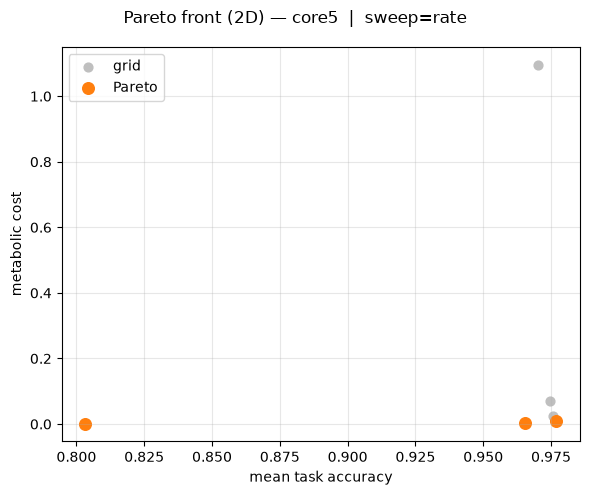

In [15]:
# Matplotlib: 2D Pareto plane for 1D sweeps, else 1x3 projection panels
pareto = df["is_pareto"].astype(bool)
battery = meta.get("task_battery", "")

if len(pareto_objectives) == 2:
    xc, yc = pareto_objectives
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(df.loc[~pareto, xc], df.loc[~pareto, yc], c="0.75", s=40, label="grid")
    ax.scatter(df.loc[pareto, xc], df.loc[pareto, yc], c="C1", s=70, label="Pareto")
    ax.set_xlabel(OBJECTIVE_LABELS[xc])
    ax.set_ylabel(OBJECTIVE_LABELS[yc])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.suptitle(f"Pareto front (2D) — {battery}  |  sweep={sweep_mode}")
else:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    if len(pareto_objectives) == 3:
        a, b, c = pareto_objectives
        pairs = [(a, b), (a, c), (b, c)]
    else:
        pairs = [
            ("task_loss", "metabolic_cost"),
            ("task_loss", "wiring_cost"),
            ("metabolic_cost", "wiring_cost"),
        ]
    for ax, (xc, yc) in zip(axes, pairs):
        ax.scatter(df.loc[~pareto, xc], df.loc[~pareto, yc], c="0.75", s=40, label="grid")
        ax.scatter(df.loc[pareto, xc], df.loc[pareto, yc], c="C1", s=70, label="Pareto")
        ax.set_xlabel(OBJECTIVE_LABELS[xc])
        ax.set_ylabel(OBJECTIVE_LABELS[yc])
        ax.grid(True, alpha=0.3)
    axes[0].legend(loc="best")
    fig.suptitle(f"Pareto front (2D projections) — {battery} ({len(df)} runs)")

fig.tight_layout()
plt.show()

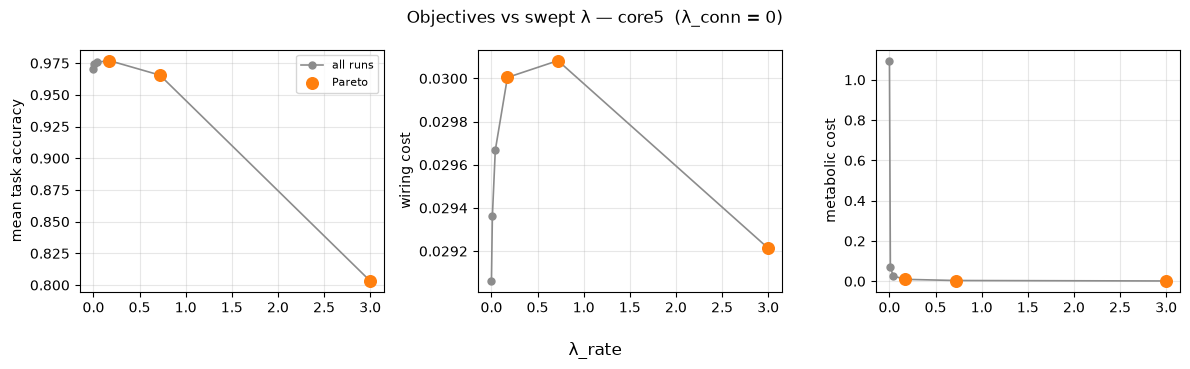

In [16]:
# Objectives vs lambda (1×3)
pareto = df["is_pareto"].astype(bool)
battery = meta.get("task_battery", "")
objective_cols = (
    ["mean_acc", "wiring_cost", "metabolic_cost"]
    if uses_mean_acc
    else ["task_loss", "wiring_cost", "metabolic_cost"]
)

if sweep_mode in ("connectivity", "rate"):
    lam_col = "lambda_connectivity" if sweep_mode == "connectivity" else "lambda_rate"
    lam_label = "λ_connectivity" if sweep_mode == "connectivity" else "λ_rate"
    plot_df = df.sort_values(lam_col)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True)
    for ax, col in zip(axes, objective_cols):
        ax.plot(
            plot_df[lam_col],
            plot_df[col],
            "o-",
            color="0.55",
            markersize=5,
            linewidth=1.2,
            label="all runs",
        )
        p = plot_df.loc[plot_df["is_pareto"].astype(bool)]
        ax.scatter(p[lam_col], p[col], c="C1", s=70, zorder=3, label="Pareto")
        ax.set_ylabel(OBJECTIVE_LABELS[col])
        ax.grid(True, alpha=0.3)

    axes[0].legend(loc="best", fontsize=8)
    fig.supxlabel(lam_label)
    fixed = (
        f"λ_rate = {df['lambda_rate'].iloc[0]:.4g}"
        if sweep_mode == "connectivity"
        else f"λ_conn = {df['lambda_connectivity'].iloc[0]:.4g}"
    )
    fig.suptitle(f"Objectives vs swept λ — {battery}  ({fixed})")
else:
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    for ax, col in zip(axes, objective_cols):
        sc = ax.scatter(
            df["lambda_rate"],
            df[col],
            c=df["lambda_connectivity"],
            cmap="viridis",
            s=45,
            alpha=0.85,
        )
        ax.scatter(
            df.loc[pareto, "lambda_rate"],
            df.loc[pareto, col],
            facecolors="none",
            edgecolors="C1",
            s=100,
            linewidths=1.8,
            label="Pareto",
        )
        ax.set_xlabel("λ_rate")
        ax.set_ylabel(OBJECTIVE_LABELS[col])
        ax.grid(True, alpha=0.3)
    axes[0].legend(loc="best", fontsize=8)
    fig.colorbar(sc, ax=axes, label="λ_connectivity", fraction=0.025, pad=0.02)
    fig.suptitle(f"Objectives vs λ_rate (color = λ_conn) — {battery}")

fig.tight_layout()
plt.show()

In [17]:
cols = [
    "lambda_rate",
    "lambda_connectivity",
    "mean_acc",
    "min_task_acc",
    "task_loss",
    "metabolic_cost",
    "wiring_cost",
    "is_pareto",
]
cols = [c for c in cols if c in df.columns]
sort_cols = (
    ["mean_acc", "metabolic_cost", "wiring_cost"]
    if uses_mean_acc
    else ["task_loss", "metabolic_cost", "wiring_cost"]
)
df.sort_values(sort_cols, ascending=[False, True, True] if uses_mean_acc else True)[cols]

,lambda_rate,lambda_connectivity,mean_acc,min_task_acc,task_loss,metabolic_cost,wiring_cost,is_pareto
3,0.173205,0.0,0.976979,0.885417,0.002726,0.009518,0.030005,True
2,0.041618,0.0,0.975729,0.879167,0.002551,0.025775,0.029667,False
1,0.010000,0.0,0.974479,0.872396,0.002775,0.069126,0.029361,False
0,0.000000,0.0,0.970208,0.853125,0.003579,1.095414,0.029062,False
4,0.720843,0.0,0.965521,0.830208,0.003559,0.003756,0.030083,True
5,3.000000,0.0,0.803229,0.563021,0.012766,0.001486,0.029214,True
